In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size="6" color="red">01. 딥러닝/머신러닝입문 회귀분석</font></b>

# 1. 기존의 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 :
https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)

https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-maermse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
 - https://www.mql5.com/ko/articles/11200

In [1]:
# 섭씨온도(input data = 독립변수)를 화씨온도(target data = 종속변수)를 출력
def celsius_to_fahrenheit(c):
    return c*1.8 + 32

In [3]:
input_c = int(input('섭씨 온도는?'))
print('화씨온도는', celsius_to_fahrenheit(input_c))

섭씨 온도는?5
화씨온도는 41.0


# 2. 딥러닝/ 머신러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : 스케일 조정, 훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋
- 3. 모델구성
- 4. 모델 학습 과정 설정
- 5. 모델 학습시키기(훈련, 검증데이터셋)
- 6. 모델 평가하기(시험데이터셋)
- 7. 모델 저장/사용(입력값이 주어지면 예측값을 받기) 
## 2.1 노이즈가 없는 데이터 실습

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

In [7]:
# 1. 데이터 확보(생성)
data_c = np.arange(100)
data_c # input데이터(독립변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [8]:
data_F = celsius_to_fahrenheit(data_c)
data_F

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [11]:
# 2. 데이터 전처리 : 스케일조정(컴퓨터에게 학습시키기 위해 정규화/표준화) : 전체의 편차를 비슷하게
scaled_data_c = data_c/100.0
scaled_data_F = data_F/100.0
scaled_data_F
print('독립변수 :', scaled_data_c)
print('')
print('타겟변수 :', scaled_data_F)

독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]

타겟변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.

In [15]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Input, Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Input(shape=(1,))) # 입력(독립)변수의 shape
model.add(Dense(1)) # 타겟(종속, 출력)변수의 갯수
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [16]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop',metrics=['mae'])
#              손실함수         옵티마이저          평가지표

In [18]:
# 학습 전 예측
model.predict(np.array([[0],[0.01]]))

1/1 [==============================] - 0s 104ms/step


array([[0.        ],
       [0.00372872]], dtype=float32)

In [19]:
# 학습 전 모델 저장
model.save('model/before_learning.h5')

In [20]:
# 5. 모델 학습시키기 - 셀 1번만 실행
hist = model.fit(scaled_data_c,scaled_data_F, epochs=1000, verbose=2)
#             독립변수(훈련data),타겟데이터(훈련date), 학습횟수, 학습시출력여부(0은 출력x, 2는 자세히)

Epoch 1/1000
4/4 - 0s - loss: 1.2122 - mae: 1.0217 - 263ms/epoch - 66ms/step
Epoch 2/1000
4/4 - 0s - loss: 1.1873 - mae: 1.0102 - 5ms/epoch - 1ms/step
Epoch 3/1000
4/4 - 0s - loss: 1.1686 - mae: 1.0015 - 0s/epoch - 0s/step
Epoch 4/1000
4/4 - 0s - loss: 1.1541 - mae: 0.9946 - 4ms/epoch - 1ms/step
Epoch 5/1000
4/4 - 0s - loss: 1.1416 - mae: 0.9889 - 0s/epoch - 0s/step
Epoch 6/1000
4/4 - 0s - loss: 1.1280 - mae: 0.9824 - 12ms/epoch - 3ms/step
Epoch 7/1000
4/4 - 0s - loss: 1.1144 - mae: 0.9761 - 2ms/epoch - 473us/step
Epoch 8/1000
4/4 - 0s - loss: 1.1006 - mae: 0.9694 - 0s/epoch - 0s/step
Epoch 9/1000
4/4 - 0s - loss: 1.0886 - mae: 0.9637 - 15ms/epoch - 4ms/step
Epoch 10/1000
4/4 - 0s - loss: 1.0768 - mae: 0.9580 - 0s/epoch - 0s/step
Epoch 11/1000
4/4 - 0s - loss: 1.0646 - mae: 0.9521 - 0s/epoch - 0s/step
Epoch 12/1000
4/4 - 0s - loss: 1.0523 - mae: 0.9462 - 4ms/epoch - 1ms/step
Epoch 13/1000
4/4 - 0s - loss: 1.0410 - mae: 0.9405 - 0s/epoch - 0s/step
Epoch 14/1000
4/4 - 0s - loss: 1.0300 -

Epoch 111/1000
4/4 - 0s - loss: 0.2237 - mae: 0.3906 - 0s/epoch - 0s/step
Epoch 112/1000
4/4 - 0s - loss: 0.2195 - mae: 0.3866 - 5ms/epoch - 1ms/step
Epoch 113/1000
4/4 - 0s - loss: 0.2147 - mae: 0.3819 - 0s/epoch - 0s/step
Epoch 114/1000
4/4 - 0s - loss: 0.2103 - mae: 0.3778 - 0s/epoch - 0s/step
Epoch 115/1000
4/4 - 0s - loss: 0.2054 - mae: 0.3728 - 2ms/epoch - 530us/step
Epoch 116/1000
4/4 - 0s - loss: 0.2011 - mae: 0.3687 - 0s/epoch - 0s/step
Epoch 117/1000
4/4 - 0s - loss: 0.1963 - mae: 0.3639 - 15ms/epoch - 4ms/step
Epoch 118/1000
4/4 - 0s - loss: 0.1914 - mae: 0.3591 - 1ms/epoch - 364us/step
Epoch 119/1000
4/4 - 0s - loss: 0.1870 - mae: 0.3546 - 0s/epoch - 0s/step
Epoch 120/1000
4/4 - 0s - loss: 0.1826 - mae: 0.3502 - 14ms/epoch - 4ms/step
Epoch 121/1000
4/4 - 0s - loss: 0.1788 - mae: 0.3462 - 0s/epoch - 0s/step
Epoch 122/1000
4/4 - 0s - loss: 0.1746 - mae: 0.3420 - 0s/epoch - 0s/step
Epoch 123/1000
4/4 - 0s - loss: 0.1702 - mae: 0.3376 - 15ms/epoch - 4ms/step
Epoch 124/1000
4/4 

Epoch 220/1000
4/4 - 0s - loss: 0.0314 - mae: 0.1529 - 14ms/epoch - 4ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.0310 - mae: 0.1522 - 1ms/epoch - 295us/step
Epoch 222/1000
4/4 - 0s - loss: 0.0307 - mae: 0.1512 - 0s/epoch - 0s/step
Epoch 223/1000
4/4 - 0s - loss: 0.0303 - mae: 0.1504 - 15ms/epoch - 4ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.0300 - mae: 0.1496 - 0s/epoch - 0s/step
Epoch 225/1000
4/4 - 0s - loss: 0.0297 - mae: 0.1488 - 0s/epoch - 0s/step
Epoch 226/1000
4/4 - 0s - loss: 0.0294 - mae: 0.1480 - 5ms/epoch - 1ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.0290 - mae: 0.1470 - 1ms/epoch - 252us/step
Epoch 228/1000
4/4 - 0s - loss: 0.0286 - mae: 0.1462 - 0s/epoch - 0s/step
Epoch 229/1000
4/4 - 0s - loss: 0.0283 - mae: 0.1453 - 2ms/epoch - 511us/step
Epoch 230/1000
4/4 - 0s - loss: 0.0280 - mae: 0.1445 - 0s/epoch - 0s/step
Epoch 231/1000
4/4 - 0s - loss: 0.0277 - mae: 0.1436 - 14ms/epoch - 3ms/step
Epoch 232/1000
4/4 - 0s - loss: 0.0274 - mae: 0.1428 - 931us/epoch - 233us/step
Epoch 233

Epoch 329/1000
4/4 - 0s - loss: 0.0053 - mae: 0.0629 - 16ms/epoch - 4ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.0052 - mae: 0.0620 - 0s/epoch - 0s/step
Epoch 331/1000
4/4 - 0s - loss: 0.0050 - mae: 0.0614 - 0s/epoch - 0s/step
Epoch 332/1000
4/4 - 0s - loss: 0.0049 - mae: 0.0606 - 16ms/epoch - 4ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.0048 - mae: 0.0599 - 0s/epoch - 0s/step
Epoch 334/1000
4/4 - 0s - loss: 0.0047 - mae: 0.0590 - 0s/epoch - 0s/step
Epoch 335/1000
4/4 - 0s - loss: 0.0045 - mae: 0.0582 - 16ms/epoch - 4ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.0044 - mae: 0.0575 - 0s/epoch - 0s/step
Epoch 337/1000
4/4 - 0s - loss: 0.0043 - mae: 0.0566 - 0s/epoch - 0s/step
Epoch 338/1000
4/4 - 0s - loss: 0.0042 - mae: 0.0557 - 17ms/epoch - 4ms/step
Epoch 339/1000
4/4 - 0s - loss: 0.0040 - mae: 0.0548 - 0s/epoch - 0s/step
Epoch 340/1000
4/4 - 0s - loss: 0.0039 - mae: 0.0541 - 0s/epoch - 0s/step
Epoch 341/1000
4/4 - 0s - loss: 0.0038 - mae: 0.0531 - 17ms/epoch - 4ms/step
Epoch 342/1000
4/4 - 0s

Epoch 434/1000
4/4 - 0s - loss: 8.9042e-07 - mae: 9.2644e-04 - 0s/epoch - 0s/step
Epoch 435/1000
4/4 - 0s - loss: 6.8372e-07 - mae: 8.0555e-04 - 13ms/epoch - 3ms/step
Epoch 436/1000
4/4 - 0s - loss: 3.7733e-07 - mae: 6.0158e-04 - 0s/epoch - 0s/step
Epoch 437/1000
4/4 - 0s - loss: 6.6881e-07 - mae: 7.9991e-04 - 0s/epoch - 0s/step
Epoch 438/1000
4/4 - 0s - loss: 1.4986e-07 - mae: 3.6807e-04 - 16ms/epoch - 4ms/step
Epoch 439/1000
4/4 - 0s - loss: 8.3346e-07 - mae: 8.8262e-04 - 5ms/epoch - 1ms/step
Epoch 440/1000
4/4 - 0s - loss: 8.6064e-07 - mae: 8.8930e-04 - 5ms/epoch - 1ms/step
Epoch 441/1000
4/4 - 0s - loss: 4.2100e-07 - mae: 6.2761e-04 - 2ms/epoch - 468us/step
Epoch 442/1000
4/4 - 0s - loss: 4.6248e-07 - mae: 6.6407e-04 - 0s/epoch - 0s/step
Epoch 443/1000
4/4 - 0s - loss: 3.9545e-07 - mae: 6.1358e-04 - 14ms/epoch - 4ms/step
Epoch 444/1000
4/4 - 0s - loss: 1.2331e-06 - mae: 0.0011 - 1ms/epoch - 296us/step
Epoch 445/1000
4/4 - 0s - loss: 1.6276e-07 - mae: 3.9219e-04 - 0s/epoch - 0s/step

Epoch 533/1000
4/4 - 0s - loss: 4.1666e-07 - mae: 6.3279e-04 - 2ms/epoch - 436us/step
Epoch 534/1000
4/4 - 0s - loss: 3.9964e-07 - mae: 6.1798e-04 - 0s/epoch - 0s/step
Epoch 535/1000
4/4 - 0s - loss: 1.0135e-06 - mae: 9.8505e-04 - 14ms/epoch - 3ms/step
Epoch 536/1000
4/4 - 0s - loss: 9.5757e-08 - mae: 2.9883e-04 - 1ms/epoch - 269us/step
Epoch 537/1000
4/4 - 0s - loss: 3.0881e-07 - mae: 5.3045e-04 - 0s/epoch - 0s/step
Epoch 538/1000
4/4 - 0s - loss: 1.5198e-06 - mae: 0.0012 - 16ms/epoch - 4ms/step
Epoch 539/1000
4/4 - 0s - loss: 2.9176e-07 - mae: 5.1850e-04 - 0s/epoch - 0s/step
Epoch 540/1000
4/4 - 0s - loss: 2.9596e-07 - mae: 5.3103e-04 - 0s/epoch - 0s/step
Epoch 541/1000
4/4 - 0s - loss: 2.2508e-07 - mae: 4.4916e-04 - 17ms/epoch - 4ms/step
Epoch 542/1000
4/4 - 0s - loss: 1.5255e-06 - mae: 0.0012 - 0s/epoch - 0s/step
Epoch 543/1000
4/4 - 0s - loss: 4.0550e-07 - mae: 5.9264e-04 - 0s/epoch - 0s/step
Epoch 544/1000
4/4 - 0s - loss: 1.8619e-07 - mae: 4.1266e-04 - 17ms/epoch - 4ms/step
Epoc

Epoch 632/1000
4/4 - 0s - loss: 1.3984e-06 - mae: 0.0012 - 14ms/epoch - 3ms/step
Epoch 633/1000
4/4 - 0s - loss: 6.2749e-07 - mae: 7.6016e-04 - 2ms/epoch - 485us/step
Epoch 634/1000
4/4 - 0s - loss: 1.8175e-08 - mae: 1.2887e-04 - 0s/epoch - 0s/step
Epoch 635/1000
4/4 - 0s - loss: 1.6917e-07 - mae: 3.8125e-04 - 14ms/epoch - 3ms/step
Epoch 636/1000
4/4 - 0s - loss: 1.8926e-06 - mae: 0.0013 - 0s/epoch - 0s/step
Epoch 637/1000
4/4 - 0s - loss: 6.4591e-08 - mae: 2.4609e-04 - 0s/epoch - 0s/step
Epoch 638/1000
4/4 - 0s - loss: 2.4222e-08 - mae: 1.4688e-04 - 15ms/epoch - 4ms/step
Epoch 639/1000
4/4 - 0s - loss: 7.7367e-07 - mae: 8.1074e-04 - 970us/epoch - 242us/step
Epoch 640/1000
4/4 - 0s - loss: 1.0009e-06 - mae: 9.7076e-04 - 0s/epoch - 0s/step
Epoch 641/1000
4/4 - 0s - loss: 5.2498e-07 - mae: 6.9473e-04 - 14ms/epoch - 3ms/step
Epoch 642/1000
4/4 - 0s - loss: 2.3952e-07 - mae: 4.7776e-04 - 1ms/epoch - 251us/step
Epoch 643/1000
4/4 - 0s - loss: 1.9909e-07 - mae: 4.2196e-04 - 0s/epoch - 0s/ste

Epoch 731/1000
4/4 - 0s - loss: 5.2967e-07 - mae: 7.1058e-04 - 17ms/epoch - 4ms/step
Epoch 732/1000
4/4 - 0s - loss: 1.0233e-06 - mae: 9.6962e-04 - 0s/epoch - 0s/step
Epoch 733/1000
4/4 - 0s - loss: 3.4235e-07 - mae: 5.6803e-04 - 0s/epoch - 0s/step
Epoch 734/1000
4/4 - 0s - loss: 4.2590e-07 - mae: 6.3198e-04 - 2ms/epoch - 500us/step
Epoch 735/1000
4/4 - 0s - loss: 9.7068e-07 - mae: 9.5874e-04 - 0s/epoch - 0s/step
Epoch 736/1000
4/4 - 0s - loss: 2.5420e-07 - mae: 4.9238e-04 - 14ms/epoch - 3ms/step
Epoch 737/1000
4/4 - 0s - loss: 6.5678e-07 - mae: 7.9387e-04 - 4ms/epoch - 973us/step
Epoch 738/1000
4/4 - 0s - loss: 6.9343e-07 - mae: 8.1768e-04 - 0s/epoch - 0s/step
Epoch 739/1000
4/4 - 0s - loss: 6.1109e-07 - mae: 7.6503e-04 - 12ms/epoch - 3ms/step
Epoch 740/1000
4/4 - 0s - loss: 4.1119e-07 - mae: 6.2921e-04 - 0s/epoch - 0s/step
Epoch 741/1000
4/4 - 0s - loss: 3.2004e-07 - mae: 5.5311e-04 - 0s/epoch - 0s/step
Epoch 742/1000
4/4 - 0s - loss: 7.5577e-07 - mae: 8.3822e-04 - 16ms/epoch - 4ms/s

Epoch 830/1000
4/4 - 0s - loss: 5.5810e-07 - mae: 7.2133e-04 - 3ms/epoch - 735us/step
Epoch 831/1000
4/4 - 0s - loss: 3.1298e-07 - mae: 5.4665e-04 - 0s/epoch - 0s/step
Epoch 832/1000
4/4 - 0s - loss: 6.9563e-07 - mae: 8.1222e-04 - 13ms/epoch - 3ms/step
Epoch 833/1000
4/4 - 0s - loss: 5.7625e-07 - mae: 7.4529e-04 - 2ms/epoch - 514us/step
Epoch 834/1000
4/4 - 0s - loss: 7.0065e-07 - mae: 8.1996e-04 - 3ms/epoch - 872us/step
Epoch 835/1000
4/4 - 0s - loss: 3.9982e-07 - mae: 6.2115e-04 - 0s/epoch - 0s/step
Epoch 836/1000
4/4 - 0s - loss: 7.2366e-07 - mae: 8.3564e-04 - 14ms/epoch - 4ms/step
Epoch 837/1000
4/4 - 0s - loss: 5.8247e-07 - mae: 7.4787e-04 - 1ms/epoch - 311us/step
Epoch 838/1000
4/4 - 0s - loss: 3.8686e-07 - mae: 6.0952e-04 - 0s/epoch - 0s/step
Epoch 839/1000
4/4 - 0s - loss: 8.1977e-07 - mae: 8.8567e-04 - 14ms/epoch - 4ms/step
Epoch 840/1000
4/4 - 0s - loss: 3.1555e-07 - mae: 5.4870e-04 - 0s/epoch - 0s/step
Epoch 841/1000
4/4 - 0s - loss: 5.7229e-07 - mae: 7.3375e-04 - 0s/epoch -

Epoch 929/1000
4/4 - 0s - loss: 1.3307e-06 - mae: 0.0011 - 13ms/epoch - 3ms/step
Epoch 930/1000
4/4 - 0s - loss: 1.3693e-07 - mae: 3.6058e-04 - 2ms/epoch - 539us/step
Epoch 931/1000
4/4 - 0s - loss: 2.1635e-07 - mae: 4.5128e-04 - 0s/epoch - 0s/step
Epoch 932/1000
4/4 - 0s - loss: 1.2923e-06 - mae: 0.0011 - 14ms/epoch - 3ms/step
Epoch 933/1000
4/4 - 0s - loss: 3.4014e-07 - mae: 5.6583e-04 - 0s/epoch - 0s/step
Epoch 934/1000
4/4 - 0s - loss: 2.7064e-07 - mae: 5.0554e-04 - 0s/epoch - 0s/step
Epoch 935/1000
4/4 - 0s - loss: 1.1561e-06 - mae: 0.0010 - 16ms/epoch - 4ms/step
Epoch 936/1000
4/4 - 0s - loss: 6.2113e-07 - mae: 7.5858e-04 - 0s/epoch - 0s/step
Epoch 937/1000
4/4 - 0s - loss: 1.1460e-07 - mae: 3.3075e-04 - 0s/epoch - 0s/step
Epoch 938/1000
4/4 - 0s - loss: 1.1909e-07 - mae: 3.0993e-04 - 16ms/epoch - 4ms/step
Epoch 939/1000
4/4 - 0s - loss: 1.8818e-06 - mae: 0.0013 - 0s/epoch - 0s/step
Epoch 940/1000
4/4 - 0s - loss: 1.2106e-07 - mae: 3.3818e-04 - 0s/epoch - 0s/step
Epoch 941/1000
4

In [21]:
# 6. 모델 과정 시각화
hist.history.keys()

dict_keys(['loss', 'mae'])

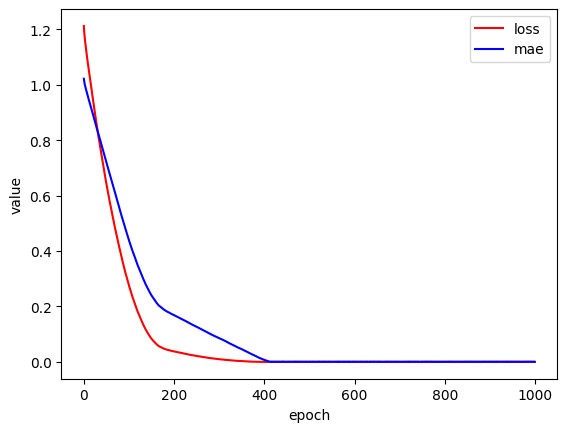

In [26]:
plt.plot(hist.history['loss'],'r',label='loss')
plt.plot(hist.history['mae'],'b',label='mae')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('value')
plt.show()

In [27]:
# 7. 모델 사용/저장
model.predict(np.array([[0],[0.01],[0.02]]))

1/1 [==============================] - 0s 25ms/step


array([[0.32028148],
       [0.33828384],
       [0.35628623]], dtype=float32)

In [28]:
model.save('model/after_learning.h5')

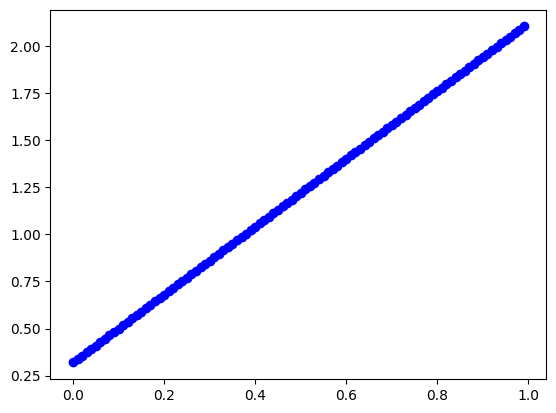

In [29]:
plt.scatter(x=scaled_data_c, y=scaled_data_F, c='b')

In [35]:
y_hat = model.predict([scaled_data_c])
for h, y in zip(y_hat[::20], scaled_data_F[::20]):
    print(h,y)

4/4 [==============================] - 0s 5ms/step
[0.32028148] 0.32
[0.680329] 0.68
[1.0403765] 1.04
[1.4004241] 1.4
[1.7604717] 1.76


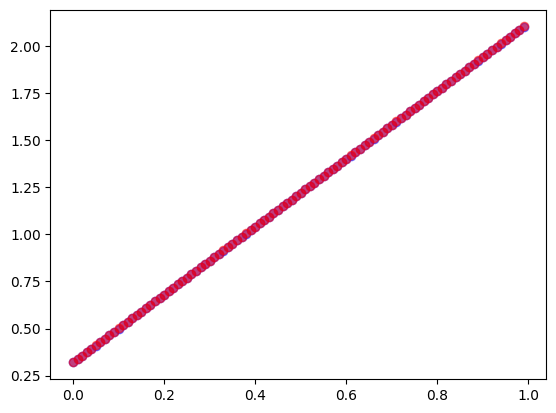

In [37]:
plt.scatter(x=scaled_data_c, y=scaled_data_F, c='b', alpha=0.5)
plt.scatter(x=scaled_data_c, y=y_hat, c='r', alpha=0.5)
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [50]:
# noise : 평균 0, 표준편차 0.1인 데이터 100개
np.random.seed(707)
noise = np.random.normal(0, scale=0.1, size=100)
noised_scaled_data_F = scaled_data_F + noise
print('독립변수 :',scaled_data_c[:10])
print('타겟변수 :',noised_scaled_data_F[:10])

독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]
타겟변수 : [0.27500034 0.20410134 0.39498826 0.27117424 0.26897164 0.35314388
 0.4496784  0.42612159 0.49409646 0.45740286]


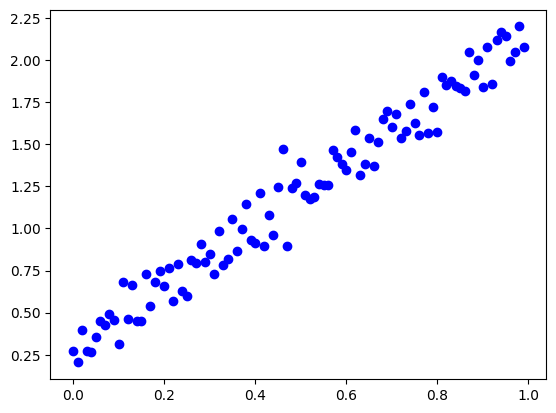

In [49]:
plt.scatter(x=scaled_data_c, y=noised_scaled_data_F, c='b')

In [76]:
# 3. 모델 구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
model2.summary()
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
# 5. 학습시키기
hist = model2.fit(scaled_data_c, noised_scaled_data_F,epochs=1500, verbose=2)

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1500
4/4 - 0s - loss: 4.2816 - mae: 1.8515 - 219ms/epoch - 55ms/step
Epoch 2/1500
4/4 - 0s - loss: 4.2359 - mae: 1.8401 - 19ms/epoch - 5ms/step
Epoch 3/1500
4/4 - 0s - loss: 4.2040 - mae: 1.8322 - 0s/epoch - 0s/step
Epoch 4/1500
4/4 - 0s - loss: 4.1763 - mae: 1.8252 - 11ms/epoch - 3ms/step
Epoch 5/1500
4/4 - 0s - loss: 4.1502 - mae: 1.8187 - 3ms/epoch - 644us/step
Epoch 6/1500
4/4 - 0s - loss: 4.1262 - mae: 1.8128 - 0s/epoch - 0s/step
Epoch 7/1500
4/4 - 0s - loss: 4.1007 - mae: 1.8063 - 4ms/epoch - 1ms/step
Epoch 8/1500
4/4 - 0s - loss: 4.0748 - mae: 1.7997 - 0s/epoch - 0s/

4/4 - 0s - loss: 2.2134 - mae: 1.2591 - 2ms/epoch - 487us/step
Epoch 104/1500
4/4 - 0s - loss: 2.1971 - mae: 1.2538 - 0s/epoch - 0s/step
Epoch 105/1500
4/4 - 0s - loss: 2.1798 - mae: 1.2483 - 13ms/epoch - 3ms/step
Epoch 106/1500
4/4 - 0s - loss: 2.1632 - mae: 1.2428 - 2ms/epoch - 419us/step
Epoch 107/1500
4/4 - 0s - loss: 2.1491 - mae: 1.2382 - 0s/epoch - 0s/step
Epoch 108/1500
4/4 - 0s - loss: 2.1333 - mae: 1.2330 - 14ms/epoch - 3ms/step
Epoch 109/1500
4/4 - 0s - loss: 2.1161 - mae: 1.2274 - 3ms/epoch - 770us/step
Epoch 110/1500
4/4 - 0s - loss: 2.0992 - mae: 1.2218 - 0s/epoch - 0s/step
Epoch 111/1500
4/4 - 0s - loss: 2.0844 - mae: 1.2169 - 4ms/epoch - 1ms/step
Epoch 112/1500
4/4 - 0s - loss: 2.0683 - mae: 1.2116 - 0s/epoch - 0s/step
Epoch 113/1500
4/4 - 0s - loss: 2.0523 - mae: 1.2062 - 0s/epoch - 0s/step
Epoch 114/1500
4/4 - 0s - loss: 2.0361 - mae: 1.2006 - 4ms/epoch - 1ms/step
Epoch 115/1500
4/4 - 0s - loss: 2.0215 - mae: 1.1958 - 0s/epoch - 0s/step
Epoch 116/1500
4/4 - 0s - loss:

Epoch 212/1500
4/4 - 0s - loss: 0.8694 - mae: 0.7589 - 2ms/epoch - 620us/step
Epoch 213/1500
4/4 - 0s - loss: 0.8606 - mae: 0.7551 - 0s/epoch - 0s/step
Epoch 214/1500
4/4 - 0s - loss: 0.8510 - mae: 0.7509 - 12ms/epoch - 3ms/step
Epoch 215/1500
4/4 - 0s - loss: 0.8416 - mae: 0.7468 - 4ms/epoch - 928us/step
Epoch 216/1500
4/4 - 0s - loss: 0.8343 - mae: 0.7435 - 0s/epoch - 0s/step
Epoch 217/1500
4/4 - 0s - loss: 0.8275 - mae: 0.7405 - 13ms/epoch - 3ms/step
Epoch 218/1500
4/4 - 0s - loss: 0.8188 - mae: 0.7365 - 0s/epoch - 0s/step
Epoch 219/1500
4/4 - 0s - loss: 0.8103 - mae: 0.7329 - 0s/epoch - 0s/step
Epoch 220/1500
4/4 - 0s - loss: 0.8016 - mae: 0.7290 - 15ms/epoch - 4ms/step
Epoch 221/1500
4/4 - 0s - loss: 0.7958 - mae: 0.7263 - 0s/epoch - 0s/step
Epoch 222/1500
4/4 - 0s - loss: 0.7893 - mae: 0.7234 - 0s/epoch - 0s/step
Epoch 223/1500
4/4 - 0s - loss: 0.7813 - mae: 0.7199 - 16ms/epoch - 4ms/step
Epoch 224/1500
4/4 - 0s - loss: 0.7727 - mae: 0.7160 - 0s/epoch - 0s/step
Epoch 225/1500
4/4

Epoch 321/1500
4/4 - 0s - loss: 0.3405 - mae: 0.5064 - 14ms/epoch - 4ms/step
Epoch 322/1500
4/4 - 0s - loss: 0.3390 - mae: 0.5052 - 572us/epoch - 143us/step
Epoch 323/1500
4/4 - 0s - loss: 0.3370 - mae: 0.5038 - 0s/epoch - 0s/step
Epoch 324/1500
4/4 - 0s - loss: 0.3348 - mae: 0.5020 - 15ms/epoch - 4ms/step
Epoch 325/1500
4/4 - 0s - loss: 0.3338 - mae: 0.5012 - 0s/epoch - 0s/step
Epoch 326/1500
4/4 - 0s - loss: 0.3327 - mae: 0.5004 - 0s/epoch - 0s/step
Epoch 327/1500
4/4 - 0s - loss: 0.3310 - mae: 0.4991 - 16ms/epoch - 4ms/step
Epoch 328/1500
4/4 - 0s - loss: 0.3296 - mae: 0.4981 - 0s/epoch - 0s/step
Epoch 329/1500
4/4 - 0s - loss: 0.3280 - mae: 0.4968 - 0s/epoch - 0s/step
Epoch 330/1500
4/4 - 0s - loss: 0.3263 - mae: 0.4955 - 4ms/epoch - 896us/step
Epoch 331/1500
4/4 - 0s - loss: 0.3246 - mae: 0.4941 - 0s/epoch - 0s/step
Epoch 332/1500
4/4 - 0s - loss: 0.3237 - mae: 0.4933 - 0s/epoch - 0s/step
Epoch 333/1500
4/4 - 0s - loss: 0.3222 - mae: 0.4921 - 3ms/epoch - 647us/step
Epoch 334/1500


4/4 - 0s - loss: 0.2270 - mae: 0.4082 - 0s/epoch - 0s/step
Epoch 430/1500
4/4 - 0s - loss: 0.2262 - mae: 0.4075 - 0s/epoch - 0s/step
Epoch 431/1500
4/4 - 0s - loss: 0.2253 - mae: 0.4066 - 5ms/epoch - 1ms/step
Epoch 432/1500
4/4 - 0s - loss: 0.2245 - mae: 0.4059 - 1ms/epoch - 251us/step
Epoch 433/1500
4/4 - 0s - loss: 0.2236 - mae: 0.4051 - 8ms/epoch - 2ms/step
Epoch 434/1500
4/4 - 0s - loss: 0.2230 - mae: 0.4045 - 2ms/epoch - 460us/step
Epoch 435/1500
4/4 - 0s - loss: 0.2220 - mae: 0.4035 - 0s/epoch - 0s/step
Epoch 436/1500
4/4 - 0s - loss: 0.2210 - mae: 0.4026 - 13ms/epoch - 3ms/step
Epoch 437/1500
4/4 - 0s - loss: 0.2200 - mae: 0.4017 - 2ms/epoch - 574us/step
Epoch 438/1500
4/4 - 0s - loss: 0.2191 - mae: 0.4008 - 0s/epoch - 0s/step
Epoch 439/1500
4/4 - 0s - loss: 0.2183 - mae: 0.4000 - 13ms/epoch - 3ms/step
Epoch 440/1500
4/4 - 0s - loss: 0.2175 - mae: 0.3993 - 1ms/epoch - 331us/step
Epoch 441/1500
4/4 - 0s - loss: 0.2167 - mae: 0.3984 - 0s/epoch - 0s/step
Epoch 442/1500
4/4 - 0s - l

...

Epoch 970/1500
4/4 - 0s - loss: 0.0115 - mae: 0.0899 - 5ms/epoch - 1ms/step
Epoch 971/1500
4/4 - 0s - loss: 0.0115 - mae: 0.0896 - 1ms/epoch - 332us/step
Epoch 972/1500
4/4 - 0s - loss: 0.0115 - mae: 0.0898 - 0s/epoch - 0s/step
Epoch 973/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0896 - 4ms/epoch - 995us/step
Epoch 974/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0896 - 0s/epoch - 0s/step
Epoch 975/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0896 - 10ms/epoch - 3ms/step
Epoch 976/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0895 - 4ms/epoch - 996us/step
Epoch 977/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0894 - 0s/epoch - 0s/step
Epoch 978/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0896 - 10ms/epoch - 3ms/step
Epoch 979/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0895 - 3ms/epoch - 746us/step
Epoch 980/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0895 - 0s/epoch - 0s/step
Epoch 981/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0893 - 11ms/epoch - 3ms/step
Epoch 982/1500
4/4 - 0s - loss: 0.0114 - mae: 0.0893 - 4ms/epoch - 1ms/step
Epoch 983

Epoch 1077/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1078/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 11ms/epoch - 3ms/step
Epoch 1079/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 3ms/epoch - 760us/step
Epoch 1080/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1081/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0879 - 11ms/epoch - 3ms/step
Epoch 1082/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 3ms/epoch - 714us/step
Epoch 1083/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0882 - 0s/epoch - 0s/step
Epoch 1084/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0879 - 13ms/epoch - 3ms/step
Epoch 1085/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1086/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1087/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 357us/epoch - 89us/step
Epoch 1088/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1089/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epo

Epoch 1184/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0881 - 0s/epoch - 0s/step
Epoch 1185/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 10ms/epoch - 3ms/step
Epoch 1186/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0879 - 3ms/epoch - 749us/step
Epoch 1187/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1188/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 11ms/epoch - 3ms/step
Epoch 1189/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0881 - 4ms/epoch - 1ms/step
Epoch 1190/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 0s/epoch - 0s/step
Epoch 1191/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0879 - 12ms/epoch - 3ms/step
Epoch 1192/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0881 - 3ms/epoch - 829us/step
Epoch 1193/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 0s/epoch - 0s/step
Epoch 1194/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 13ms/epoch - 3ms/step
Epoch 1195/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0879 - 2ms/epoch - 578us/step
Epoch 1196/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step

Epoch 1291/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1292/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 362us/epoch - 90us/step
Epoch 1293/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1294/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 17ms/epoch - 4ms/step
Epoch 1295/1500
4/4 - 0s - loss: 0.0109 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1296/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1297/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 17ms/epoch - 4ms/step
Epoch 1298/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1299/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 0s/epoch - 0s/step
Epoch 1300/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 16ms/epoch - 4ms/step
Epoch 1301/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0876 - 0s/epoch - 0s/step
Epoch 1302/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1303/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 17ms/epoch - 4ms/step
Epoch 13

4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 12ms/epoch - 3ms/step
Epoch 1399/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 2ms/epoch - 570us/step
Epoch 1400/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0880 - 0s/epoch - 0s/step
Epoch 1401/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 4ms/epoch - 1ms/step
Epoch 1402/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1403/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0876 - 10ms/epoch - 3ms/step
Epoch 1404/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0876 - 4ms/epoch - 996us/step
Epoch 1405/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 0s/epoch - 0s/step
Epoch 1406/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0878 - 10ms/epoch - 3ms/step
Epoch 1407/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 3ms/epoch - 831us/step
Epoch 1408/1500
4/4 - 0s - loss: 0.0109 - mae: 0.0876 - 0s/epoch - 0s/step
Epoch 1409/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0877 - 12ms/epoch - 3ms/step
Epoch 1410/1500
4/4 - 0s - loss: 0.0110 - mae: 0.0876 - 3ms/epoch - 827us/step
Epoch 1411/

In [77]:
# 6. 학습과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'mae'])

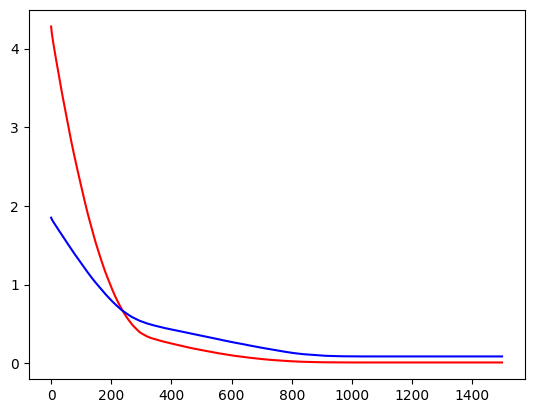

In [78]:
plt.plot(hist.history['loss'],'r')
plt.plot(hist.history['mae'],'b')
plt.show()

In [79]:
# 7. 모델 사용
model2.predict(np.array([[-0.01]
                        ,[0]
                        ,[0.01]
                        ,[0.02]]))

1/1 [==============================] - 0s 39ms/step


array([[0.2680405 ],
       [0.28669018],
       [0.30533984],
       [0.3239895 ]], dtype=float32)

In [80]:
y_hat = model2.predict([scaled_data_c])
for h,y in zip(y_hat[::20], noised_scaled_data_F[::20]):
    print(h,y)

4/4 [==============================] - 0s 1ms/step
[0.28669018] 0.2750003435726217
[0.65968347] 0.6573517921634632
[1.0326768] 0.9109195630083544
[1.4056702] 1.3455450551349164
[1.7786634] 1.5738145874658984


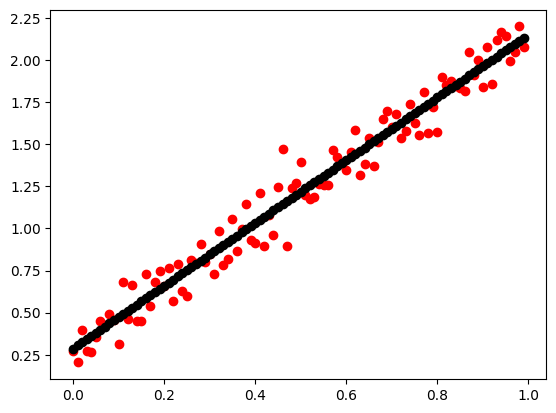

In [81]:
plt.scatter(x=scaled_data_c, y=noised_scaled_data_F, c='r')
plt.scatter(x=scaled_data_c, y=y_hat, c='k')

In [83]:
# 모델 저장
model2.save('model/noised_after_learning.h5')
# from tensorflow.keras.models import save_model
# save_model(model2,'model/noised_after_learning.h5')
# save_model(model2,'model/noised_after_learning.keras')

In [85]:
# 저장된 모델 사용하기
from tensorflow.keras.models import load_model
model3=load_model('model/noised_after_learning.h5')

In [86]:
model3.predict(np.array([[-0.01],
                        [0],
                        [0.01]]))

1/1 [==============================] - 0s 31ms/step


array([[0.2680405 ],
       [0.28669018],
       [0.30533984]], dtype=float32)